Mounted at /content/drive
Folders in dataset directory: ['Augmented Curry Leaf', 'Augmented Arjun Leaf', 'Augmented Marsh Pennywort Leaf', 'Augmented Mint Leaf', 'Augmented Neem Leaf', 'Augmented Rubble Leaf']
Found 7724 images belonging to 6 classes.
Found 1931 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 3528s 4s/step - accuracy: 0.4121 - loss: 1.3019 - val_accuracy: 0.6950 - val_loss: 0.7404
Epoch 2/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 541s 560ms/step - accuracy: 0.7017 - loss: 0.7295 - val_accuracy: 0.8177 - val_loss: 0.4448
Epoch 3/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 527s 546ms/step - accuracy: 0.8698 - loss: 0.3698 - val_accuracy: 0.8224 - val_loss: 0.5251
Epoch 4/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 521s 540ms/step - accuracy: 0.9251 - loss: 0.2342 - val_accuracy: 0.9726 - val_loss: 0.0831
Epoch 5/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 518s 536ms/step - accuracy: 0.9537 - loss: 0.1493 - val_accuracy: 0.9637 - val_loss: 0.1258
Epoch 6/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 517s 535ms/step - accuracy: 0.9562 - loss: 0.1223 - val_accuracy: 0.9456 - val_loss: 0.1638
Epoch 7/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 554s 574ms/step - accuracy: 0.9527 - loss: 0.1379 - val_accuracy: 0.9591 - val_loss: 0.1157
Epoch 8/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 517s 535ms/step - accuracy: 0.9660 - l

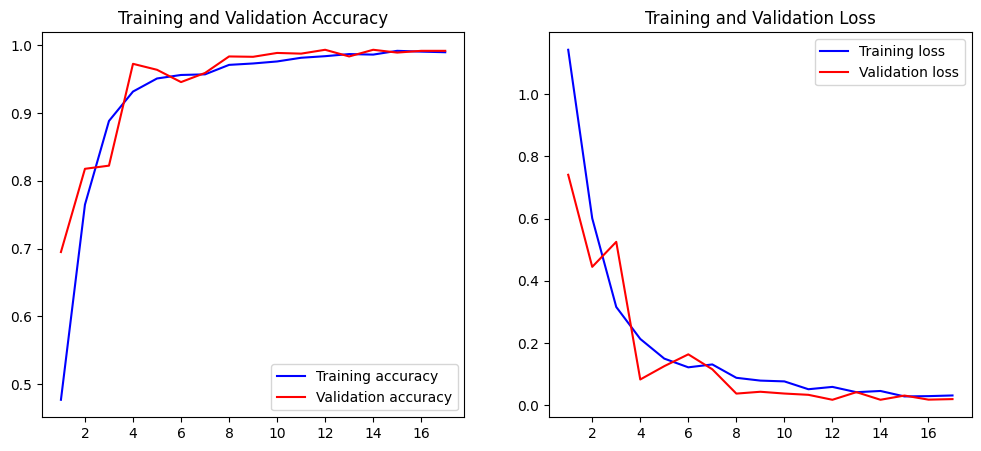

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import os



data_dir = "/content/drive/MyDrive/augmented_dataset/new/Augmented Images (Version 02)"



#if the images are not loading properly then use this to check are they even present or not
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Dataset directory '{data_dir}' not found. Check your Google Drive path.")

print("Folders in dataset directory:", os.listdir(data_dir))









# rescale, rotate and cropping
datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)





train_data = datagen.flow_from_directory(
    directory=data_dir,
    target_size=(150, 150),
    batch_size=8,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    directory=data_dir,
    target_size=(150, 150),
    batch_size=8,
    class_mode='categorical',
    subset='validation'
)



# basic cnn model but effective with augmented data
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])



#high learning rate to increase the efficiency
initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate, decay_steps=1000, decay_rate=0.9, staircase=True
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)


#training on fixed epoch and early stop if it overfits
history = model.fit(
    train_data,
    epochs=25,
    validation_data=val_data,
    callbacks=[early_stopping]
)



#saving the model
model_save_path = "/content/drive/MyDrive/Optimized_Leaf_Model.keras"
model.save(model_save_path)
print(f"Model saved at {model_save_path}")





# basic graph code to check accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


import tensorflow as tf

# loading saved model from drive
model_path = "/content/drive/MyDrive/Optimized_Leaf_Model.keras"
model = tf.keras.models.load_model(model_path)

print("✅ Model Loaded Successfully!")


Mounted at /content/drive
✅ Model Loaded Successfully!


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# image input here
image_path = "image6.jpg"

# use small size, but can increase it to 260x260 too
img = image.load_img(image_path, target_size=(150, 150))


img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

print("Image Preprocessed Successfully!")



✅ Image Preprocessed Successfully!


In [ ]:
class_labels = [
    "Augmented Arjun Leaf",
    "Augmented Curry Leaf",
    "Augmented Marsh Pennywort Leaf",
    "Augmented Mint Leaf",
    "Augmented Neem Leaf",
    "Augmented Rubble Leaf"
]


In [ ]:
predictions = model.predict(img_array)

predicted_class_index = np.argmax(predictions, axis=1)[0]

confidence = predictions[0][predicted_class_index] * 100



predicted_class_name = class_labels[predicted_class_index]

# result and values
print(predictions)
print(class_labels)
print(f"Predicted Class: {predicted_class_name} ({confidence:.2f}% confidence)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[2.6617287e-17 3.5415633e-07 1.4586217e-20 1.7571566e-16 9.9999964e-01
  8.7741744e-13]]
['Augmented Arjun Leaf', 'Augmented Curry Leaf', 'Augmented Marsh Pennywort Leaf', 'Augmented Mint Leaf', 'Augmented Neem Leaf', 'Augmented Rubble Leaf']
Predicted Class: Augmented Neem Leaf (100.00% confidence)


In [ ]:
# percentage accuracy

Curry Leaf: 0.00%
Arjun Leaf: 0.00%
Marsh Pennywort Leaf: 99.99%
Mint Leaf: 0.00%
Neem Leaf: 0.00%
Rubble Leaf: 0.01%


In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import Required Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks, applications
import matplotlib.pyplot as plt
import os

# Step 3: Define Dataset Path
dataset_path = "/content/drive/MyDrive/augmented_dataset/new/Augmented Images (Version 02)"

# Step 4: Check if Dataset Exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset directory '{dataset_path}' not found. Check your Google Drive path.")

# Step 5: Data Augmentation and Loading
datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load Training and Validation Data
train_data = datagen.flow_from_directory(
    directory=dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    directory=dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_data.num_classes

# Step 6: Define the AlexNet Model
def build_alexnet():
    model = models.Sequential([
        layers.Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(150, 150, 3)),
        layers.MaxPooling2D((3, 3), strides=(2, 2)),

        layers.Conv2D(256, (5, 5), activation='relu', padding="same"),
        layers.MaxPooling2D((3, 3), strides=(2, 2)),

        layers.Conv2D(384, (3, 3), activation='relu', padding="same"),
        layers.Conv2D(384, (3, 3), activation='relu', padding="same"),
        layers.Conv2D(256, (3, 3), activation='relu', padding="same"),
        layers.MaxPooling2D((3, 3), strides=(2, 2)),

        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Step 7: Define Pretrained Models (VGG16, ResNet50, MobileNetV2)
def build_vgg16():
    base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    base_model.trainable = False  # Freeze the base model
    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_resnet50():
    base_model = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    base_model.trainable = False
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_mobilenetv2():
    base_model = applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    base_model.trainable = False
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Step 8: Training Function
def train_model(model, model_name, epochs=25):
    print(f"\nTraining {model_name}...\n")

    # Learning Rate Scheduling
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=1000, decay_rate=0.9, staircase=True
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping
    early_stopping = callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    )

    # Training
    history = model.fit(
        train_data,
        epochs=epochs,
        validation_data=val_data,
        callbacks=[early_stopping]
    )

    # Save the model
    model_save_path = f"/content/drive/MyDrive/{model_name}.h5"
    model.save(model_save_path)
    print(f"{model_name} saved at {model_save_path}")

    return history

# Step 9: Train Each Model and Plot Results
models_to_train = {
    "AlexNet": build_alexnet(),
    "VGG16": build_vgg16(),
    "ResNet50": build_resnet50(),
    "MobileNetV2": build_mobilenetv2()
}

histories = {}

for model_name, model in models_to_train.items():
    histories[model_name] = train_model(model, model_name)

# Step 10: Plot Training Results
plt.figure(figsize=(15, 10))

for i, (model_name, history) in enumerate(histories.items()):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.subplot(2, 2, i+1)
    plt.plot(epochs, acc, 'b', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
    plt.title(f'{model_name}: Accuracy')
    plt.legend()

plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 7724 images belonging to 6 classes.
Found 1931 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


<ipython-input-38-dde41e296c9b>:101: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training AlexNet...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 3455s 14s/step - accuracy: 0.1575 - loss: 2.1140 - val_accuracy: 0.1668 - val_loss: 1.7923
Epoch 2/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 660s 3s/step - accuracy: 0.1669 - loss: 1.7927 - val_accuracy: 0.1668 - val_loss: 1.7919
Epoch 3/25
 71/242 ━━━━━━━━━━━━━━━━━━━━ 7:13 3s/step - accuracy: 0.1792 - loss: 1.7916

KeyboardInterrupt: 

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import Required Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks, applications
import os

# Step 3: Define Dataset Path
dataset_path = "/content/drive/MyDrive/augmented_dataset/new/Augmented Images (Version 02)"

# Step 4: Data Augmentation (Improves Model Generalization)
datagen = ImageDataGenerator(
    rescale=1.0/255.0,  # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 80% Training, 20% Validation
)

# Step 5: Load Training and Validation Data
train_data = datagen.flow_from_directory(
    directory=dataset_path,
    target_size=(224, 224),  # Recommended for MobileNetV2
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    directory=dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_data.num_classes  # Auto-detect number of classes

# Step 6: Build MobileNetV2 Model
def build_mobilenetv2():
    base_model = applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze layers for transfer learning

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),  # Prevent overfitting
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Step 7: Train MobileNetV2 Model
def train_model(model, epochs=20):
    print("\nTraining MobileNetV2...\n")

    # Learning Rate Scheduling
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=1000, decay_rate=0.9, staircase=True
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping to prevent overfitting
    early_stopping = callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    )

    # Train Model
    history = model.fit(
        train_data,
        epochs=epochs,
        validation_data=val_data,
        callbacks=[early_stopping]
    )

    # Save the model in Keras format
    model.save("/content/drive/MyDrive/optimized_model1.keras")  # ✅ FIXED

    print("✅ Model saved successfully as 'optimized_model1.keras'")

    return history

# Step 8: Run Training
mobilenet_model = build_mobilenetv2()
mobilenet_history = train_model(mobilenet_model, epochs=20)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 7724 images belonging to 6 classes.
Found 1931 images belonging to 6 classes.

Training MobileNetV2...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.9191 - loss: 0.2450 - val_accuracy: 0.9984 - val_loss: 0.0066
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 601s 2s/step - accuracy: 0.9950 - loss: 0.0184 - val_accuracy: 0.9995 - val_loss: 0.0027
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 594s 2s/step - accuracy: 0.9970 - loss: 0.0113 - val_accuracy: 0.9943 - val_loss: 0.0168
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 547s 2s/step - accuracy: 0.9953 - loss: 0.0106 - val_accuracy: 0.9979 - val_loss: 0.0086
Epoch 5/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 567s 2s/step - accuracy: 0.9990 - loss: 0.0037 - val_accuracy: 0.9984 - val_loss: 0.0029
Epoch 6/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 632s 2s/step - accuracy: 0.9995 - loss: 0.0030 - val_accuracy: 0.9984 - val_loss: 0.0032
Epoch 7/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 617s 2s/step - accuracy: 0.9979 - loss: 0.0063 - val_accuracy: 0.9995 - val_loss: 0.0020
✅ Model saved successfully as 'optimized_model1.keras'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, fbeta_score
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import os

# Step 9: Evaluate Model on Validation Data
def evaluate_model(model, val_data):
    y_true = val_data.classes  # True labels
    y_pred_probs = model.predict(val_data)  # Predicted probabilities
    y_pred = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class indices

    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1-score:", f1_score(y_true, y_pred, average='weighted'))
    print("F2-score:", fbeta_score(y_true, y_pred, beta=2, average='weighted'))

    return y_true, y_pred

# Step 10: Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

# Step 11: Accuracy & Loss Graphs
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Model Accuracy")

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Model Loss")

    plt.show()

# Evaluate Model
y_true, y_pred = evaluate_model(mobilenet_model, val_data)
plot_confusion_matrix(y_true, y_pred, list(train_data.class_indices.keys()))
plot_training_history(mobilenet_history)

# Step 12: Predict on a Single Image
def predict_image(img_path, model, class_names):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]
    predicted_class = np.argmax(predictions)

    print(f"Predicted Class: {class_names[predicted_class]}")
    print("Class Probabilities:")
    for i, class_name in enumerate(class_names):
        print(f"{class_name}: {predictions[i]*100:.2f}%")

    plt.imshow(img)
    plt.title(f"Prediction: {class_names[predicted_class]}")
    plt.axis('off')
    plt.show()

# Example Usage (Provide your image path)
# predict_image('/content/sample_image.jpg', mobilenet_model, list(train_data.class_indices.keys()))


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "mobilenetv2_1.00_224" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(32, 150, 150, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 150, 150, 3), dtype=float32)
  • training=False
  • mask=None

Folders in dataset: ['Augmented Curry Leaf', 'Augmented Arjun Leaf', 'Augmented Marsh Pennywort Leaf', 'Augmented Mint Leaf', 'Augmented Neem Leaf', 'Augmented Rubble Leaf']
Found 7724 images belonging to 6 classes.
Found 1931 images belonging to 6 classes.


<ipython-input-41-52b90e80e460>:52: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')


Epoch 1/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.8511 - loss: 0.4234 - val_accuracy: 0.9845 - val_loss: 0.0487
Epoch 2/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - accuracy: 0.9713 - loss: 0.0839 - val_accuracy: 0.9860 - val_loss: 0.0423
Epoch 3/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.9783 - loss: 0.0606 - val_accuracy: 0.9922 - val_loss: 0.0192
Epoch 4/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.9806 - loss: 0.0554 - val_accuracy: 0.9834 - val_loss: 0.0466
Epoch 5/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.9795 - loss: 0.0540 - val_accuracy: 0.9943 - val_loss: 0.0167
Epoch 6/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9817 - loss: 0.0459 - val_accuracy: 0.9855 - val_loss: 0.0437
Epoch 7/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9817 - loss: 0.0505 - val_accuracy: 0.9917 - val_loss: 0.0249
Epoch 8/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9799 - loss: 0.0539 - val_accu

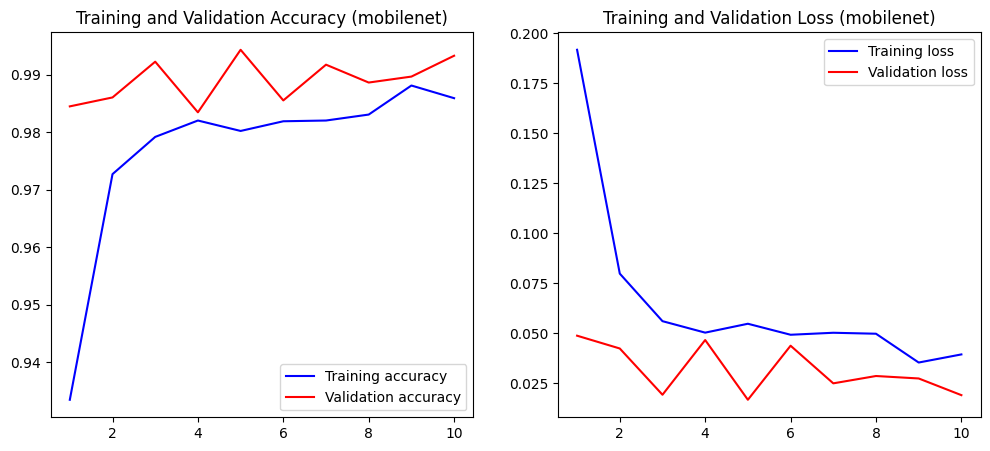

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import os

# Define dataset path
dataset_path = "/content/drive/MyDrive/augmented_dataset/new/Augmented Images (Version 02)"

# Check dataset folders
print("Folders in dataset:", os.listdir(dataset_path))

# Define image parameters
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 25

# Data augmentation and preprocessing
datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 80% train, 20% validation
)

# Load the images
train_data = datagen.flow_from_directory(
    directory=dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    directory=dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Select Model: Choose 'mobilenet', 'resnet', or 'vgg'
MODEL_NAME = 'mobilenet'  # Change to 'resnet' or 'vgg' to try different models

if MODEL_NAME == 'mobilenet':
    base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
elif MODEL_NAME == 'resnet':
    base_model = ResNet50(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
elif MODEL_NAME == 'vgg':
    base_model = VGG16(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
else:
    raise ValueError("Invalid model name! Choose from 'mobilenet', 'resnet', or 'vgg'.")

# Freeze the base model
base_model.trainable = False

# Build the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')  # Output layer
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    callbacks=[early_stopping]
)

# Save the trained model in Keras format
model.save(f"{MODEL_NAME}_leaf_model.keras")

# Plot accuracy & loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title(f'Training and Validation Accuracy ({MODEL_NAME})')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title(f'Training and Validation Loss ({MODEL_NAME})')
plt.legend()

plt.show()


✅ Model Loaded Successfully!
Found 9655 images belonging to 6 classes.
302/302 ━━━━━━━━━━━━━━━━━━━━ 449s 1s/step

📊 Classification Report:
                                 precision    recall  f1-score   support

          Augmented Arjun Leaf       1.00      1.00      1.00      1605
          Augmented Curry Leaf       1.00      1.00      1.00      1610
Augmented Marsh Pennywort Leaf       1.00      1.00      1.00      1610
           Augmented Mint Leaf       1.00      1.00      1.00      1610
           Augmented Neem Leaf       1.00      1.00      1.00      1610
         Augmented Rubble Leaf       1.00      1.00      1.00      1610

                      accuracy                           1.00      9655
                     macro avg       1.00      1.00      1.00      9655
                  weighted avg       1.00      1.00      1.00      9655

✅ Accuracy: 0.9997928534438115
✅ Precision: 0.9997931104494643
✅ Recall: 0.9997928534438115
✅ F1-score: 0.9997928855595009
✅ F2-score: 0.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


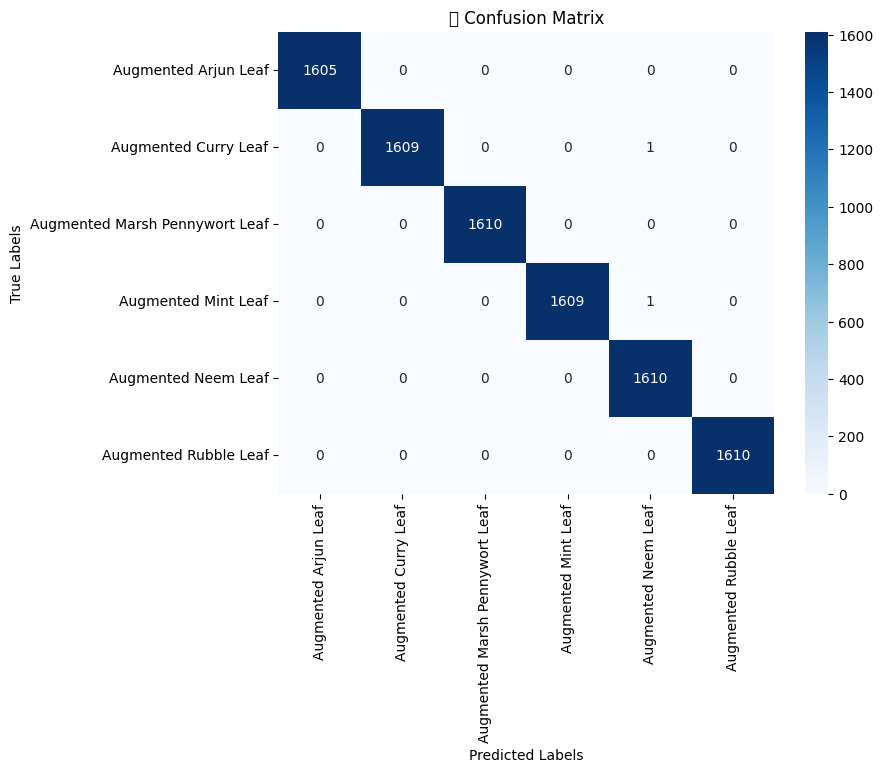

In [ ]:
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, fbeta_score
import matplotlib.pyplot as plt

# ✅ Load the trained model
model_path = "/content/mobilenet_leaf_model.keras"
model = load_model(model_path)
print("✅ Model Loaded Successfully!")

# ✅ Ensure correct input size
IMG_SIZE = (224, 224)  # Matches training size
BATCH_SIZE = 32

# ✅ Dataset Path
dataset_path = "/content/drive/MyDrive/augmented_dataset/new/Augmented Images (Version 02)"

# ✅ Load validation dataset with correct preprocessing
datagen = ImageDataGenerator(rescale=1.0/255.0)

val_data = datagen.flow_from_directory(
    directory=dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important for evaluation
)

# ✅ Get ground truth labels
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# ✅ Predict on validation dataset
y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Print classification report with proper formatting
print("\n📊 Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))
print("✅ Accuracy:", accuracy_score(y_true, y_pred))
print("✅ Precision:", precision_score(y_true, y_pred, average='weighted'))
print("✅ Recall:", recall_score(y_true, y_pred, average='weighted'))
print("✅ F1-score:", f1_score(y_true, y_pred, average='weighted'))
print("✅ F2-score:", fbeta_score(y_true, y_pred, beta=2, average='weighted'))

# ✅ Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("📊 Confusion Matrix")
    plt.show()

plot_confusion_matrix(y_true, y_pred, class_names)


✅ Model Loaded Successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

🎯 Predicted Class: Augmented Neem Leaf
📊 Class Probabilities:
Augmented Arjun Leaf: 0.13%
Augmented Curry Leaf: 0.00%
Augmented Marsh Pennywort Leaf: 0.00%
Augmented Mint Leaf: 0.01%
Augmented Neem Leaf: 87.65%
Augmented Rubble Leaf: 12.21%


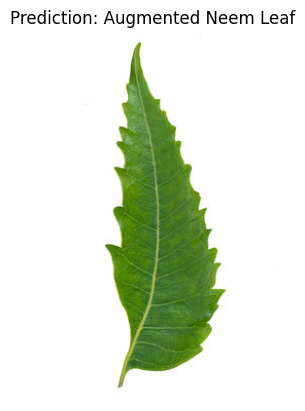

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# ✅ Load the trained model
model_path = "/content/mobilenet_leaf_model.keras"
model = load_model(model_path)
print("✅ Model Loaded Successfully!")

# ✅ Define class names (Replace with your actual class names)
class_names = ['Augmented Arjun Leaf', 'Augmented Curry Leaf',
               'Augmented Marsh Pennywort Leaf', 'Augmented Mint Leaf',
               'Augmented Neem Leaf', 'Augmented Rubble Leaf']

# ✅ Load and preprocess the unseen image
img_path = "/content/image10.jpg"  # Ensure the file is in Colab root directory
img = image.load_img(img_path, target_size=(224, 224))  # Resize to match MobileNetV2 input
img_array = image.img_to_array(img) / 255.0  # Normalize
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# ✅ Make prediction
predictions = model.predict(img_array)[0]
predicted_class_index = np.argmax(predictions)
predicted_class = class_names[predicted_class_index]

# ✅ Print results
print(f"\n🎯 Predicted Class: {predicted_class}")
print("📊 Class Probabilities:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {predictions[i]*100:.2f}%")

# ✅ Display the image with the prediction
plt.imshow(image.load_img(img_path))
plt.title(f"Prediction: {predicted_class}")
plt.axis('off')
plt.show()

Mounted at /content/drive
Folders in dataset: ['Augmented Curry Leaf', 'Augmented Arjun Leaf', 'Augmented Marsh Pennywort Leaf', 'Augmented Mint Leaf', 'Augmented Neem Leaf', 'Augmented Rubble Leaf']
Found 7724 images belonging to 6 classes.
Found 1931 images belonging to 6 classes.

Building MOBILENET model...



<ipython-input-1-9b97f37dc6be>:63: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MODELS[model_name](input_shape=(150, 150, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training MOBILENET...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 5264s 22s/step - accuracy: 0.8496 - loss: 0.4284 - val_accuracy: 0.9798 - val_loss: 0.0545
Epoch 2/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 90s 373ms/step - accuracy: 0.9697 - loss: 0.0797 - val_accuracy: 0.9865 - val_loss: 0.0335
Epoch 3/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 91s 375ms/step - accuracy: 0.9806 - loss: 0.0564 - val_accuracy: 0.9912 - val_loss: 0.0290
Epoch 4/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 88s 364ms/step - accuracy: 0.9848 - loss: 0.0441 - val_accuracy: 0.9927 - val_loss: 0.0225
Epoch 5/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 142s 363ms/step - accuracy: 0.9826 - loss: 0.0590 - val_accuracy: 0.9922 - val_loss: 0.0245
Epoch 6/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 91s 377ms/step - accuracy: 0.9849 - loss: 0.0443 - val_accuracy: 0.9881 - val_loss: 0.0293
Epoch 7/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 86s 357ms/step - accuracy: 0.9789 - loss: 0.0545 - val_accuracy: 0.9891 - val_loss: 0.0294
Epoch 8/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 146s 374ms/step - accuracy: 0.9819 - loss:

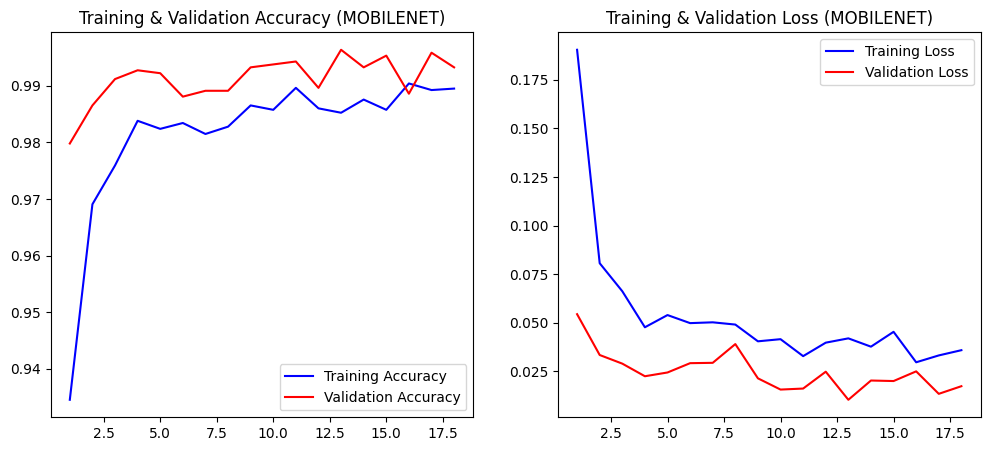


Building RESNET model...

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

Training RESNET...

Epoch 1/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 116s 429ms/step - accuracy: 0.1819 - loss: 1.8467 - val_accuracy: 0.2035 - val_loss: 1.7642
Epoch 2/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 94s 388ms/step - accuracy: 0.2287 - loss: 1.7608 - val_accuracy: 0.3164 - val_loss: 1.7216
Epoch 3/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 96s 395ms/step - accuracy: 0.2473 - loss: 1.7104 - val_accuracy: 0.3278 - val_loss: 1.6653
Epoch 4/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 93s 386ms/step - accuracy: 0.2638 - loss: 1.6805 - val_accuracy: 0.3765 - val_loss: 1.6120
Epoch 5/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 93s 383ms/step - accuracy: 0.2965 - loss: 1.6302 - val_accuracy: 0.3573 - val_loss: 1.5799
Epoch 6/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 93s 384ms/step - accuracy: 0.3224 - loss: 1.5834 - val_accuracy: 0.3988 - val_loss: 1.5225
Epoch 7/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 92s 382ms/step - accuracy: 0.3391 - loss: 1.5540 - val_accuracy: 0.4329 - 

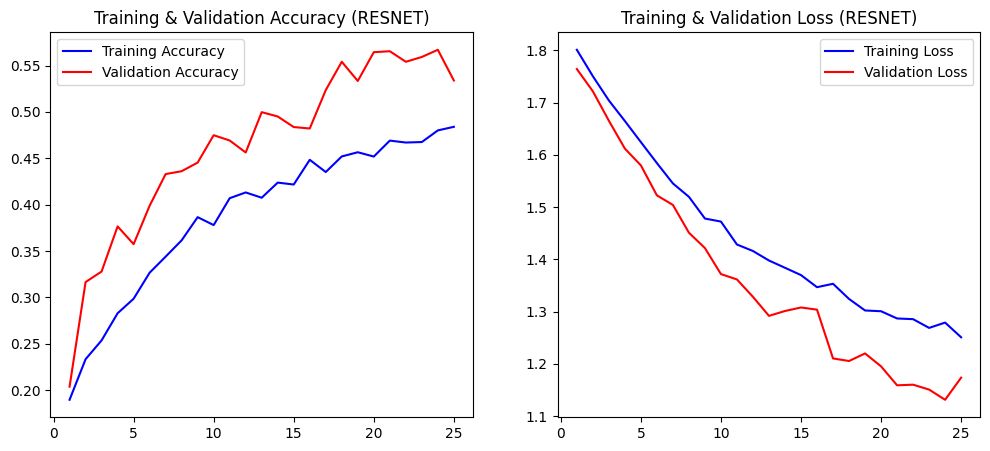


Building VGG model...

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Training VGG...

Epoch 1/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 110s 420ms/step - accuracy: 0.6493 - loss: 0.9866 - val_accuracy: 0.9467 - val_loss: 0.2250
Epoch 2/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 93s 383ms/step - accuracy: 0.9396 - loss: 0.2158 - val_accuracy: 0.9637 - val_loss: 0.1361
Epoch 3/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 95s 391ms/step - accuracy: 0.9546 - loss: 0.1502 - val_accuracy: 0.9684 - val_loss: 0.1064
Epoch 4/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 94s 388ms/step - accuracy: 0.9585 - loss: 0.1275 - val_accuracy: 0.9705 - val_loss: 0.0863
Epoch 5/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 94s 388ms/step - accuracy: 0.9676 - loss: 0.0996 - val_accuracy: 0.9762 - val_loss: 0.0737
Epoch 6/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 94s 388ms/step - accuracy: 0.9702 - loss: 0.0899 - val_accuracy: 0.9746 - val_loss: 0.0704
Epoch 7/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 94s 390ms/step - accuracy: 0.9764 - loss: 0.0741 - val_accuracy: 0.9767 - val_lo

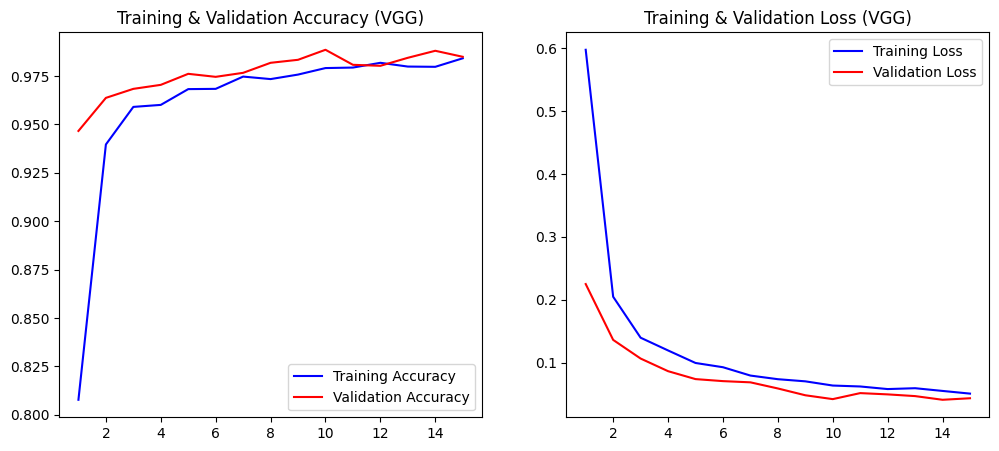

In [1]:
from IPython import get_ipython
from IPython.display import display
# %%
from google.colab import drive
drive.mount('/content/drive') # Ensure drive is mounted

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import os

dataset_path = "/content/drive/MyDrive/augmented_dataset/new/Augmented Images (Version 02)"

# Check if the path exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset directory '{dataset_path}' not found. Check your Google Drive path.")

print("Folders in dataset:", os.listdir(dataset_path))

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 25


datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    directory=dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    directory=dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Define available models
MODELS = {
    "mobilenet": MobileNetV2,
    "resnet": ResNet50,
    "vgg": VGG16
}

def build_model(model_name):
    print(f"\nBuilding {model_name.upper()} model...\n")
    base_model = MODELS[model_name](input_shape=(150, 150, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(train_data.num_classes, activation='softmax')
    ])
    return model

def train_model(model, model_name):
    print(f"\nTraining {model_name.upper()}...\n")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        train_data,
        epochs=EPOCHS,
        validation_data=val_data,
        callbacks=[early_stopping]
    )

    model.save(f"/content/drive/MyDrive/{model_name}_leaf_model.keras")
    print(f"Model saved successfully as '{model_name}_leaf_model.keras'\n")
    return history

# Train all models one by one
for model_name in MODELS.keys():
    model = build_model(model_name)
    history = train_model(model, model_name)

    # Plot training progress
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, 'b', label='Training Accuracy')
    plt.plot(epochs_range, val_acc, 'r', label='Validation Accuracy')
    plt.title(f'Training & Validation Accuracy ({model_name.upper()})')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, 'b', label='Training Loss')
    plt.plot(epochs_range, val_loss, 'r', label='Validation Loss')
    plt.title(f'Training & Validation Loss ({model_name.upper()})')
    plt.legend()

    plt.show()
